# Funktionen
Eine Funktion ist ein in sich abgeschlossener Programmteil, der eine bestimmte Aufgabe erfüllt. Funktionen helfen dabei, den Code zu strukturieren, wiederverwendbar zu machen und die Lesbarkeit zu verbessern.

### Definition einer Funktion
In Python wird eine Funktion mit dem Schlüsselwort `def` definiert, gefolgt von einem Namen und runden Klammern. Der Codeblock innerhalb der Funktion wird eingerückt.

```python
def meine_funktion():
    Anweisungen die von der Funktion ausgeführt werden
```

### Aufruf einer Funktion
Um eine Funktion auszuführen, wird ihr Name gefolgt von runden Klammern verwendet.

```python
meine_funktion()
```

Der Funktionsname (hier `meine_funktion`) ist frei wählbar und unterliegt den selben Einschränkungen und Konventionen wie Variablennamen
- nicht mit einer Zahl beginnen
- Kleinschreibung und Unterstriche
- Sprechende Namen verwenden

In [46]:
def print_greeting():
    print("Hello, welcome to EPROG!")
    print("We hope you enjoy the course.")

print_greeting()

Hello, welcome to EPROG!
We hope you enjoy the course.


__Wichtig__: Funktionen müssen definiert sein, bevor sie aufgerufen werden. Der Funktionsaufruf kann auch innerhalb anderer Funktionen oder Kontrollstrukturen erfolgen.

## Funktionsparameter und Rückgabewerte
Funktionen können Parameter haben, die beim Aufruf übergeben werden. Außerdem können sie Werte zurückgeben.
- Die Parameter werden in den runden Klammern der Funktionsdefinition angegeben und können beim Aufruf der Funktion übergeben werden.
- Rückgabewerte werden mit dem Schlüsselwort `return` angegeben.
- Die Funktion wird nach dem `return` sofort verlassen.
- Mehrere Parameter und Rückgabewerte sind durch Kommas getrennt.




In [47]:
def add_numbers(x, y):
    sum = x + y
    return sum
def multiply_numbers(x, y):
    product = x * y
    return product
def add_and_multiply(x, y):
    sum = add_numbers(x, y)
    product = multiply_numbers(x, y)
    return sum, product

sum_result, product_result = add_and_multiply(3, 4)

print("3 + 4 =", sum_result, ", 3 * 4 =", product_result)
print("3 + 4 =", add_and_multiply(3, 4)[0], ", 3 * 4 =", add_and_multiply(3, 4)[1])
print("3 + 4 =", add_numbers(3, 4), ", 3 * 4 =", multiply_numbers(3, 4))

3 + 4 = 7 , 3 * 4 = 12
3 + 4 = 7 , 3 * 4 = 12
3 + 4 = 7 , 3 * 4 = 12


### Struktur einer Funktion
Eine Funktion besteht aus __Signatur__ und __Rumpf__:
- Die Signatur umfasst den Funktionsnamen und die Parameterliste (Anzahl und Reihenfolge der Parameter ist wichtig)
- Der Rumpf enthält die Anweisungen, die ausgeführt werden, wenn die Funktion aufgerufen wird

Der selbe Funktionsname kann nicht mehrfach mit unterschiedlicher Signatur verwendet werden (keine Überladung wie in C++ oder Java)
- Bei mehrfacher Definition wird die letzte Definition verwendet

In [48]:
def f(x):
    return x**2 - 2*x + 1
def f(x,y):
    return x**2 + y**2
print(f(3))

TypeError: f() missing 1 required positional argument: 'y'

### Beispiel: Cosinus-Satz
Wenn zwei Seitenlängen $a$, $b$, und der eingeschlossene Winkel $\alpha$ eines Dreiecks gegeben sind, kann die dritte Seite $c$ mit dem Cosinus-Satz berechnet werden:

$$
c = \sqrt{a^2 + b^2 - 2ab \cdot \cos(\alpha)}
$$

In [49]:
from math import cos, sqrt, pi
def cos_law(a, b, alpha):
    csq = a**2 + b**2 - 2*a*b*cos(alpha)
    return sqrt(csq)

c = cos_law(3, 4, pi/2)
print("c =", c)

c = 5.0


### Beispiel: Ableitung einer quadratischen Funktion
Die Ableitung der Funktion $f(x) = ax^2 + bx + c$ ist $f'(x) = 2ax + b$.

In [ ]:
def diff_quadratic(a, b, c):
    print(f"The derivative of f(x) = {a}x^2 + {b}x + {c} is f'(x) = {2*a}x + {b}")

diff_quadratic(-2, 3, 1)

The derivative of f(x) = -2x^2 + 3x + 1 is f'(x) = -4x + 3


### Beispiel: Innerhalb oder außerhalb eines Polygons

Will man überprüfen ob ein Punkt innerhalb oder außerhalb eines Polygons liegt, so stellt man sich einen Strahl vor, der vom Punkt aus parallel zur x-Achse nach rechts verläuft (oder in eine beliebige andere Richtung).
- Der Punkt liegt innerhalb des Polygons, wenn der Strahl eine ungerade Anzahl an Kanten des Polygons schneidet.
- Der Punkt liegt außerhalb des Polygons, wenn der Strahl eine gerade Anzahl an Kanten des Polygons schneidet.

Um zu überprüfen ob der Strahl eine Kante von $(x_1, y_1)$ nach $(x_2, y_2)$ schneidet, müssen folgende Bedingungen erfüllt sein:
1. Der y-Wert des Punktes muss zwischen den y-Werten der Kantenendpunkte liegen: $(y_1 < y \leq y_2)$ oder $(y_2 < y \leq y_1)$
2. Der x-Wert des Punktes muss kleiner als der x-Wert des Schnittpunkts der Kante mit der horizontalen Linie durch den Punkt sein. Der x-Wert des Schnittpunkts kann mit Schlussrechnung (Dreisatz) berechnet werden:
    - $y-y_1$ verhält sich zu $y_2 - y_1$ wie $x_s - x_1$ zu $x_2 - x_1$

   $$
   \frac{y - y_1}{y_2 - y_1}= \frac{x_s - x_1}{x_2 - x_1}\quad\text{oder}\quad x_s = x_1 + \frac{(y - y_1) \cdot (x_2 - x_1)}{(y_2 - y_1)}
   $$
   
   berechnet werden. Die Bedingung lautet also: $x < x_s$

<img src="illustrations/intersection.png" width="400">

In [5]:
def inside_poly(poly, point):    
    x, y = point
    n = len(poly)
    counter = 0
    hits = []
    for i in range(n):
        x1, y1 = poly[i]
        x2, y2 = poly[(i + 1) % n]
        if ((y1<= y < y2) or (y2<= y < y1)) and (x < (x2 - x1) * (y - y1) / (y2 - y1) + x1):
            counter += 1
            hits.append((x1, y1, x2, y2))

    return counter % 2 == 1, hits

Wir testen die Funktion an einem Beispielpolygon

In [14]:
polygon1 = [(0,0), (1,0), (0.7,0.4),(1,0.6),(1.3,0.3),(1.4,0),(2,1),(0,1)]
polygon2 = [(0, -2), (-2, -1.5), (-7, -5), (-10, -3), (-14, -4), (-12, 1),
             (-16, 5), (-10, 3), (-5, 4), (-3, 2), (-4, 5), (-3, 7), (0, 5), 
             (3, 7), (4, 5), (3, 2), (5, 4), (10, 3), (16, 5), (12, 1), (14, -4), 
             (10, -3), (7, -5), (2, -1.5), (0, -2)]
point = (0.5,0.5)
inside, hits = inside_poly(polygon1, point)
print("Point", point, "inside polygon:", inside)

Point (0.5, 0.5) inside polygon: True


Um die Funktion zu testen und das Ergebnis zu visualisieren, verwenden wir die Bibliothek `matplotlib`. Diese werden wir im Kapitel 'Visualisierung mit Matplotlib' genauer kennenlernen und erklären.
Den folgenden Code können Sie vorerst ignorieren.

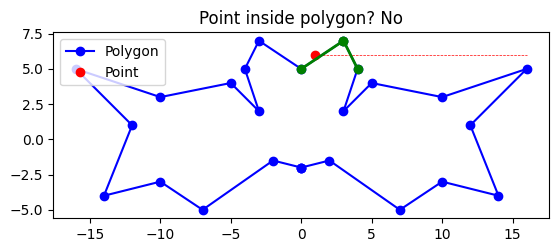

In [18]:
def draw_polygon(polygon, point, inside, hits):
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots()
    poly_closed = polygon + [polygon[0]]
    xs, ys = zip(*poly_closed)
    ax.plot(xs, ys, 'b-o', label='Polygon')
    ax.plot(point[0], point[1], 'ro', label='Point')
    ax.plot([point[0],max([x for (x,y)in polygon])],[point[1],point[1]],'r--', lw=0.5)
    for (x1, y1, x2, y2) in hits:
        ax.plot([x1, x2], [y1, y2], 'g-o', lw=2)
    ax.set_aspect('equal')
    ax.legend()
    ax.set_title("Point inside polygon?" + (" Yes" if inside else " No"))
    plt.show()

point = (1,6)
inside, hits = inside_poly(polygon2, point)
draw_polygon(polygon2, point, inside, hits)

## Optionale und benannte Parameter
In Python können Funktionen __optionale Parameter__ haben, die Standardwerte besitzen. 
- Diese Parameter müssen am Ende der Parameterliste stehen. 
- Beim Aufruf der Funktion können diese Parameter weggelassen werden, in diesem Fall wird der Standardwert verwendet. 
- Nach einem optionalen Parameter dürfen keine weiteren nicht-optionalen Parameter folgen.

In [20]:
def greet(name, greeting="Hello", punctuation = ""):
    print(greeting, name + punctuation)

greet("Alice")
greet("Bob", "Hi")
greet([1,2], "Welcome", [3,4])

Hello Alice!
Hi Bob!
Hello Diana?


### Achtung mit veränderlichen Standardwerten
 Wenn ein optionaler Parameter ein veränderliches Objekt ist (z.B. eine Liste oder ein Wörterbuch), können unerwartete Ergebnisse auftreten.
- Der Standardwert wird nur einmal bei der Definition der Funktion erstellt, nicht bei jedem Aufruf.
- Änderungen am Standardwert in einem Funktionsaufruf wirken sich auf alle zukünftigen Aufrufe aus, die den Standardwert verwenden.

In [22]:
def append_to_list(value, lst=[]):
    lst.append(value)
    return lst

list1 = append_to_list(1)
print("list1:", list1)
list2 = append_to_list(2)
print("list2:", list2)


list1: [1]
list2: [1, 2]


Daher sollte man nie veränderliche Objekte als Standardwerte verwenden. 
- Wenn man einen Parameter mit einem veränderlichen Objekt als Standardwert benötigt, sollte man `None` als Standardwert verwenden und innerhalb der Funktion das veränderliche Objekt erstellen.

In [ ]:
def append_to_list(value, lst=None):
    if lst is None:
        lst = []
    lst.append(value)
    return lst

list1 = append_to_list(1)
print("list1:", list1)
list2 = append_to_list(2)
print("list2:", list2)

list1: [1]
list2: [2]


### Benannte Parameter von Funktionen
In Python können Funktionen auch benannte Parameter haben. Beim Aufruf der Funktion können die Parameter explizit mit ihrem Namen angegeben werden, wodurch die Reihenfolge der Parameter beim Aufruf beliebig wird. Das ist besonders nützlich bei Funktionen mit vielen optionalen Parametern von denen man nur einige wenige ändern möchte.
- Man kann benannte und unbenannte Parameter mischen, dabei müssen die unbenannten Parameter in der richtigen Reihenfolge zuerst kommen.
- Benannte Parameter können in beliebiger Reihenfolge angegeben werden.

In [26]:
def introduce(first_name, last_name="", city="Unknown", occupation="Unemployed"):
    print("Hello, my name is", first_name, last_name + ".")
    print("I live in", city, "and work as a", occupation + ".")

introduce(occupation="Superhero", last_name="Parker", first_name="Peter", city="New York")
introduce(first_name="Michael", occupation="Clown")
introduce("Michael", occupation = "Clown")



Hello, my name is Peter Parker.
I live in New York and work as a Superhero.
Hello, my name is Michael .
I live in Unknown and work as a Clown.
Hello, my name is Michael .
I live in Unknown and work as a Clown.


## Funktionen mit beliebig vielen Parametern
Manchmal ist es nützlich, eine Funktion zu definieren, die eine variable Anzahl von Argumenten akzeptiert. In Python kann dies mit `*args` und `**kwargs` erreicht werden:
- `*args` ermöglicht es, eine beliebige Anzahl von Positionsargumenten zu übergeben. Diese werden als Tupel innerhalb der Funktion behandelt.
- `**kwargs` ermöglicht es, eine beliebige Anzahl von benannten Argumenten zu übergeben. Diese werden als Dictionary innerhalb der Funktion behandelt.
```python
def beispiel_funktion(*args, **kwargs):
```

In [ ]:
def sum_all(*args):
    if len(args) > 0:
        return sum(args)
    return None

print(sum_all(1, 2, 3)) 
print(sum_all(5, 10))

6
15


Im nächsten Beispiel wird eine Funktion definiert, der nicht nur positionelle sondern auch benannte Argumente übergeben werden können. Die Funktion sucht in den benannten Argumenten nach einem Schlüssel `car` und gibt dessen Wert aus, falls vorhanden.

In [28]:
def look_for_car(*args,**kwargs):
    print(kwargs)
    print(args)
    if 'car' in kwargs:
        #print("Found a car:", kwargs['car'])
        return True
    else:
        #print("No car found.")
        return False
found = look_for_car(3,2,1,3,car="Toyota", color="red")
look_for_car(10,13,color="blue", bike="Yamaha")

{'car': 'Toyota', 'color': 'red'}
(3, 2, 1, 3)
Found a car: Toyota
{'color': 'blue', 'bike': 'Yamaha'}
(10, 13)
No car found.


### Beispiel: innerhalb oder außerhalb eines Polygons (Version 2)
Anstelle der Funktion `inside_poly` eine `list` von Punkten zu übergeben, können wir die Funktion so anpassen, dass sie auch eine beliebige Anzahl von Punkten als separate Argumente akzeptiert.

In [12]:
def inside_poly(*args, point = (0,0)):    
    x, y = point
    n = len(args)
    if n==1:
        poly = args[0]
        n = len(poly)
    else:
        poly = args
    counter = 0
    for i in range(n):
        x1, y1 = poly[i]
        x2, y2 = poly[(i + 1) % n]
        if ((y1 > y) != (y2 > y)) and (x < (x2 - x1) * (y - y1) / (y2 - y1) + x1):
            counter += 1

    return counter % 2 == 1

inside = inside_poly((0,0), (1,0), (0,1), point=(0.3,0.5))
print("The point {0.3,0.5} is inside the polygon:", inside)
poly = [(0,0), (1,0), (0,1)]
inside = inside_poly(poly, point=(0.3,0.5))
print("The point {0.3,0.5} is inside the polygon:", inside)

The point {0.3,0.5} is inside the polygon: True
The point {0.3,0.5} is inside the polygon: True


### Was macht der `**` Operator vor `kwargs`?
Der `**` zerlegt ein `Dictionary` in einzelne Schlüssel-Wert-Paare, die dann als benannte Argumente an die Funktion übergeben werden können. 


In [29]:
def test(text,number):
    print(text * number)

test("Hello ", 3)
my_list = ["Hello ", 3]
test(*my_list) 
my_dict = {'text': "Hello ", 'number': 3}
test(**my_dict) 
test(text = "Hello ", number = 3)

Hello Hello Hello 
Hello Hello Hello 
Hello Hello Hello 
Hello Hello Hello 


Im obigen Beispiel enspricht der Aufruf `test(*my_list)` dem Aufruf `test("Hello ", 3)` und der Aufruf `test(**my_dict)` dem Aufruf `test(text="Hello ", number=3)`.

## Funktionen als Rückgabewerte
Funktionen können auch andere Funktionen als Rückgabewerte haben. Das ermöglicht es, Funktionen zu erstellen, die andere Funktionen generieren oder modifizieren.

Im folgenden Beispiel wird eine Funktion `power_function` definiert, die eine andere Funktion zurückgibt, die eine Zahl auf eine bestimmte Potenz hebt:
`square` und `cube` sind wieder Funktionen, die man aufrufen kann.

In [32]:
def power_function(exponent):
    def power(base):
        return base ** exponent
    return power

square = power_function(2)
cube = power_function(3)

print("5 squared is", square(5))
print("2 cubed is", cube(2))

5 squared is 25
2 cubed is 8


Aufmerksame LeserInnen werden sich fragen, warum die innere Funktion die Variable `exponent` kennt, obwohl diese nicht als Parameter übergeben wird.
Das liegt am `Scope` (Gültigkeitsbereich) von Variablen, der im nächsten Abschnitt erklärt wird.


## Scope von Variablen
Der Scope (Gültigkeitsbereich) einer Variable bestimmt, wo im Code die Variable zugänglich ist. In Python gibt es zwei Hauptarten von Scopes: global und lokal.
- Globale Variablen sind außerhalb von Funktionen definiert und können von überall im Code, einschließlich innerhalb von Funktionen, verwendet werden.
    - Achtung: Wenn eine globale Variable innerhalb einer Funktion verändert werden soll, muss das `global` Schlüsselwort verwendet werden (siehe weiter unten).
- Lokale Variablen sind innerhalb einer Funktion definiert und nur innerhalb dieser Funktion zugänglich. Sie existieren nur während der Ausführung der Funktion und werden gelöscht, wenn die Funktion beendet ist.
- Die Funktionen `locals()` und `globals()` können verwendet werden, um die aktuellen lokalen und globalen Variablen anzuzeigen.

Im Folgenden Beispiel wird eine globale Variable `my_pi` innerhalb der Funktion `calculate_circumference` verwendet:


In [1]:
my_pi = 3.14159
def calculate_circumference(radius):
    print("Local variables:", locals())
    return 2 * my_pi * radius
print(calculate_circumference(5))

Local variables: {'radius': 5, 'tmp': 1}
31.4159


Eine innerhalb der Funktion definierte Variable ist lokal und außerhalb der Funktion nicht zugänglich.
- Der Zugriff auf diese Variable von außerhalb der Funktion führt zu einem Fehler:

In [2]:
def set_pi():
    inside_pi = 3.14159
    print("Inside function, inside_pi =", inside_pi)

set_pi()
print("Outside function, inside_pi =", inside_pi)

{'inside_pi': 3.14159}
Inside function, inside_pi = 3.14159


NameError: name 'inside_pi' is not defined

__Wichtig__: Innerhalb der Funktion definierte Variablen können den gleichen Namen wie globale Variablen haben. In diesem Fall hat die lokale Variable Vorrang innerhalb der Funktion und überdeckt die globale Variable.

In [3]:
var1 = 10
def example_function():
    var1 = 20 
    print("Inside function, var1 =", var1)

print("Outside function, var1 =", var1)
var1=example_function()
print("Outside function after function call, var1 =", var1)


Outside function, var1 = 10
Inside function, var1 = 20
Outside function after function call, var1 = 20


### Geschachtelte Funktionen
Lokale Variablen können in verschachtelten Funktionen verwendet werden. Dabei hat die innere Funktion Zugriff auf die lokalen Variablen der äußeren Funktion.
- Variablen haben Scope innerhalb der Funktion,in der sie definiert werden
- Das inkludiert alle Funktionen, die innerhalb dieser Funktion definiert sind
- Der Scope wird nach innen vererbt!

__LEGB-Regel__: Python sucht nach Variablen in folgender Reihenfolge:
1. **L**ocal: Lokaler Scope (innerhalb der aktuellen Funktion)
2. **E**nclosing: Eingeschlossener Scope (in umgebenden Funktionen)
3. **G**lobal: Globaler Scope (außerhalb aller Funktionen)
4. **B**uilt-in: Eingebaute Funktionen und Variablen (z.B. `print`, `len`)

In [6]:
def power_function(exponent):
    print(locals())
    def power(base):
        print(locals())
        return base ** exponent
    return power
print("Call to power_function:")
square = power_function(2)
print("Call to square:")
print(square(5))

Call to power_function:
{'exponent': 2}
Call to square:
{'base': 5, 'exponent': 2}
25


### Der Scope wird vor der Ausführung festgelegt
Der Scope einer Variable wird zur Definition der Funktion festgelegt, nicht zur Ausführungszeit.
- Eine Variable die in einer Funktion zugewiesen wird ist lokal, auch schon vor der Zuweisung
- Der Aufruf von `func2()` führt zu einem Fehler, da `x` durch die Zuweisung in der Funktion als lokale Variable betrachtet wird und daher in der `print`-Anweisung noch nicht definiert ist.

In [ ]:
x = 3
def func1():
    print("Inside func1, x =", x)

def func2():
    print("Inside func2, x =", x)
    x = 2

func1()
func2()

Inside func, x = 3


UnboundLocalError: local variable 'x' referenced before assignment

### Closures und Cells
- Wenn im letzten Code-Beispiel die Funktion `square` aufgerufen wird, sollte es die lokale Variable `exponent` der Funktion `power_function` nicht mehr geben.
- Dennoch ist der Zugriff auf `exponent` in der Funktion `square` möglich. Die Variable ist auch in `locals()` sichtbar.
- Was passiert hier?

__Closures__ sind Funktionen, die eine Referenz auf Variablen aus ihrem umgebenden Scope behalten, auch wenn dieser Scope nicht mehr aktiv ist. Diese Variablen werden in sogenannten __Cells__ gespeichert.
- Vereinfacht gesagt ist eine Cell ein Abbild des Scopes an jenem Zeitpunkt an dem die umgebende Funktion endet.
- Beim Aufruf der inneren Funktion wird auf die gespeicherten Werte in den Cells zugegriffen.
- Das kann man über die versteckten Attribute (später mehr dazu) `__closure__` und `cell_contents` der Funktion herausfinden.

In [ ]:
print("The variable 'exponent' is stored in",square.__closure__)
print("The stored value of 'exponent' is", square.__closure__[0].cell_contents)

The variable 'exponent' is stored in (<cell at 0x724963449540: int object at 0x7249876ac110>,)
The stored value of 'exponent' is 2


### Das `global` Schlüsselwort
Das `global` Schlüsselwort wird verwendet, um anzugeben, dass eine Variable, die innerhalb einer Funktion definiert wurde,global sein soll. 
- Wenn es die Variable bereits gibt, wird die globale Variable verwendet und kann dadurch verändert werden.
- Wenn es die Variable noch nicht gibt, wird sie neu als globale Variable erstellt.

In [8]:
pi = 3.14159
def pi_is_exactly_3():
    global pi
    pi = 3
    
print("Before function call, pi =", pi)
pi_is_exactly_3()
print("After function call, pi =", pi)

Before function call, pi = 3.14159
After function call, pi = 3.14159


__Achtung__: Veränderbare Objekte (wie Listen oder Dictionaries) können innerhalb einer Funktion verändert werden, ohne dass das `global` Schlüsselwort verwendet werden muss.
Das führt zu unerwarteten Situationen:
- Im folgenden Beispiel macht `extend_list()` genau das erwartete, nämlich die Liste `my_list` um das Element `4` zu erweitern.
- Im Gegensatz dazu führt `extend_list2()` zu einem Fehler
    - Durch die Zuweisung `my_list = ...` wird eine neue lokale Variable `my_list` erzeugt, die die globale `my_list` verdeckt.
    - Daher wird im Rest der Zeile `my_list = my_list + [5]` auf die neue lokale Variable zugegriffen, die aber noch nicht definiert ist -> Fehler


In [12]:
my_list = [1, 2, 3]
def extend_list():
    my_list.append(4)

def extend_list2():
    global my_list
    my_list = my_list + [5]
    

print("Before function call, my_list =", my_list)
extend_list()
print("After extend_list(), my_list =", my_list)
extend_list2()
print("After extend_list2(), my_list =", my_list)

Before function call, my_list = [1, 2, 3]
After extend_list(), my_list = [1, 2, 3, 4]
After extend_list2(), my_list = [1, 2, 3, 4, 5]


### Das `nonlocal` Schlüsselwort
Das `nonlocal` Schlüsselwort wird verwendet, um anzugeben, dass eine Variable, die innerhalb einer verschachtelten Funktion definiert wurde, nicht lokal, sondern in der nächsthöheren umgebenden Funktion gesucht werden soll.
- Wenn es die Variable in der nächsthöheren umgebenden Funktion gibt, wird diese verwendet und kann dadurch verändert werden.
- Wenn es die Variable nicht gibt, wird ein Fehler ausgelöst.

In [15]:
x = 0 
def outer_function():
    x = 1 
    def inner_function():
        nonlocal x
        x = 2 
        print("Inside inner_function, x =", x)
    inner_function()
    print("Inside outer_function, x =", x)

print("Before function call, x =", x)
outer_function()
print("After function call, x =", x)

SyntaxError: no binding for nonlocal 'x' found (560640880.py, line 5)

## Decorators für Funktionen
Ein Decorator ist eine spezielle Art von Funktion, die eine andere Funktion als Argument nimmt und eine neue Funktion zurückgibt. Decorators werden verwendet, um das Verhalten von Funktionen zu ändern oder zu erweitern, ohne den ursprünglichen Funktionscode zu verändern.
- Decorators werden mit dem `@`-Symbol vor der Funktionsdefinition angewendet.

```python
def decorator_funktion(original_funktion):
    def new_function(parameters):
        ### Veränderung der Funktionalität
    return new_function

@decorator_funktion
def meine_funktion():
    ### ursprüngliche Funktionalität
```


### Beispiel: Funktionsaufrufe zählen
Im folgenden Beispiel wird ein Decorator `count_calls` definiert, der die Anzahl der Aufrufe einer Funktion zählt und ausgibt:
- Der Decorator verwendet eine globale Variable `function_calls`, um die Anzahl der Aufrufe zu speichern.
- Wir verwenden `*args` und `**kwargs`, um sicherzustellen, dass die dekorierte Funktion beliebige Argumente akzeptieren kann.

In [ ]:
function_calls = 0

def loging_decorator(func):
    def func_with_log(*args, **kwargs):
        global function_calls
        function_calls += 1
        result = func(*args, **kwargs)
        return result
    return func_with_log

@loging_decorator
def add(a, b):
        return a + b

print(add(3, 4))
print(add(10, 20))
print("Function 'add' was called", function_calls, "times.")


7
30
Function 'add' was called 2 times.


### Beispiel: Debugging Decorator
Ein weiterer nützlicher Decorator ist ein Debugging-Decorator, der die Argumente und den Rückgabewert einer Funktion ausgibt.
- `.__name__` liefert den Namen der Funktion als String 


In [ ]:
def debug_decorator(func):
    def wrapper(*args, **kwargs):
        print(f"Aufruf von {func.__name__} mit args: {args}")
        result = func(*args, **kwargs)
        print(f"{func.__name__} hat {result} zurückgegeben")
        return result
    return wrapper

@debug_decorator
def multiply(x, y):
    return x * y

print(multiply(3, 4))



Aufruf von multiply mit args: (3, 4)
multiply hat 12 zurückgegeben
12


## `lambda` Funktionen \& das `functools`-Modul
`lambda` Funktionen sind anonyme Funktionen (Funktionen ohne Namen), die in einer einzigen Zeile definiert werden können.
Syntax:
```python
lambda parameter1, parameter2, ... : ausdruck
```
- `lambda` Funktionen können beliebig viele Parameter haben, aber nur einen Ausdruck, der ausgewertet und zurückgegeben wird.
- Sie sind nützlich für kurze Funktionen, die nur einmal verwendet werden, z.B. als Argumente für andere Funktionen wie `map()`, `filter()` und `sort()`.

In [ ]:
absmax = lambda x, y: x if abs(x) > abs(y) else y
print(absmax(-10, 5))

-10


### Beispiel: `sort()` mit benutzderfiniertem Sortierkriterium
Die eingebaute Funktion `sort()` kann mit dem Parameter `key` ein benutzerdefiniertes Ordnungskriterium verwenden, um die Sortierreihenfolge zu bestimmen.
- Das Ordnungskriterium muss ein Argument (das zu vergleichende Objekt) haben und einen Wert zurückgeben, der für die Sortierung verwendet wird.

Im folgenden Beispiel wird eine Liste Koordinaten nach ihrem Abstand vom Nullpunkt sortiert:


In [18]:
my_list = [(1, 3), (-7, 2), (5, -1), (4, 4), (-2, -6)]

my_list.sort(key=lambda x: x[0]**2+x[1]**2)
print(my_list)

[(1, 3), (5, -1), (4, 4), (-2, -6), (-7, 2)]


`sort()` versteht die lexikographische Sortierung von Strings. Damit kann man auch Zahlen lexikographisch ordnen:

In [22]:
my_list = [1, 14, 2,25,534,21,111]
my_list.sort(key=lambda x: str(x))
print(my_list)

[1, 111, 14, 2, 21, 25, 534]


Kann man zwei Objekte nicht natürlich einordnen, sondern nur vergleichen, so muss man eine benutzerdefinierte Vergleichsfunktion verwenden.

- Diese Funktion muss zwei Argumente (die zu vergleichenden Objekte) haben und einen Wert zurückgeben, der für die Sortierung verwendet wird.
    - Negativer Wert, wenn das erste Objekt kleiner ist
    - Null, wenn beide Objekte gleich sind
    - Positiver Wert, wenn das erste Objekt größer ist



In [24]:
from functools import cmp_to_key
my_list = ["Hallo", "lo", "allo", "o", "text"]
my_list.sort(key = cmp_to_key(lambda x,y: x.find(y)))
print(my_list)

['text', 'o', 'lo', 'allo', 'Hallo']


### Beispiel: `map()`
`map()` ist eine eingebaute Funktion in Python, die eine gegebene Funktion auf alle Elemente eines iterierbaren Objekts (Liste, Tupel, Set,...) anwendet und ein neues iterierbares Objekt zurückgibt.

Syntax:
```python
map(funktion, iterierbares_objekt)
```
- `funktion` ist die Funktion, die auf jedes Element des iterierbaren Objekts
- `iterierbares_objekt` ist das Objekt (z.B. eine Liste), dessen Elemente verarbeitet werden sollen

Der Rückgabewert von `map()` ist ein `map` Objekt, das in eine Liste oder ein anderes iterierbares Objekt umgewandelt werden kann, wenn nötig.


In [26]:
my_list = [3, -7, 2, 5, -1]
my_squared_list = list(map(lambda x: x**2, my_list))
print(my_squared_list)
print(list(map(lambda x: x>=0, my_list)))

[9, 49, 4, 25, 1]
[True, False, True, True, False]


### Beispiel: `filter()`
`filter()` ist eine eingebaute Funktion in Python, die eine gegebene Funktion auf alle Elemente eines iterierbaren Objekts (wie einer Liste) anwendet und nur die Elemente zurückgibt, für die die Funktion `True` ergibt.
Syntax:
```python
filter(funktion, iterierbares_objekt)
```
- `funktion` ist die Funktion, die auf jedes Element des iterierbaren Objekts angewendet wird und einen booleschen Wert zurückgibt
- `iterierbares_objekt` ist das Objekt (z.B. eine Liste), dessen Elemente gefiltert werden sollen

Der Rückgabewert von `filter()` ist ein `filter` Objekt, das in eine Liste oder ein anderes iterierbares Objekt umgewandelt werden kann, wenn nötig.



In [30]:
my_list = [3, -7, 2, 5, -1]
pos_list = list(filter(lambda x: x % 2==1, my_list))
neg_list = list(filter(lambda x: x < 0, my_list))
print("Positive numbers:", pos_list)
print("Negative numbers:", neg_list)

Positive numbers: [3, -7, 5, -1]
Negative numbers: [-7, -1]


### Beispiel: `reduce()`
`reduce()` ist eine Funktion im `functools`-Modul, die eine gegebene Funktion auf die Elemente eines iterierbaren Objekts (wie einer Liste) anwendet und einen einzigen kumulierten Wert zurückgibt.
Syntax:
```python
from functools import reduce
reduce(function, iterierbares_objekt, initialwert)
```
Unten wird z.B. die Produktfunktion $(x,y)\mapsto xy$ auf die Liste $[3, -7, 2, 5, -1]$ angewendet. Intern, wird folgendermaßen gerechnet:
$$(((3 \cdot -7) \cdot 2) \cdot 5) \cdot -1 = 210$$


In [31]:
from functools import reduce
my_list = [3, -7, 2, 5, -1]
sum = reduce(lambda x, y: x + y, my_list) # Das selbe wie sum(my_list)
prod = reduce(lambda x, y: x * y, my_list)
print("Sum:", sum)
print("Product:", prod)

# Version vom Produkt mit Ausgabe der Zwischenschritte
def prod_verbose(x, y):
    print(f"Multiplying {x} and {y}")
    return x * y
reduce(prod_verbose, my_list)



Sum: 2
Product: 1
Multiplying 3 and -7
Multiplying -21 and 2
Multiplying -42 and 5
Multiplying -210 and -1


210

### Achtung: Auch `lambda` Funktionen beachten den Scope
`lambda` Funktionen verhalten sich genauso wie normale Funktionen hinsichtlich des Scopes von Variablen.
- Durch die kompakte Schreibweise wird das auch von erfahrenen Programmierern und Programmiererinnen manchmal übersehen.
- Im Beispiel unten hat die Laufvariable `i` den Wert 4 zum Zeitpunkt des Aufrufs der `lambda` Funktionen.
- Diese Verhalten hat nichts mit `lambda` Funktionen zu tun, sondern gilt für alle Funktionen.

In [33]:
func_list = []
for i in range(5):
    func_list.append(lambda x: x + i)
    
for f in func_list:
    print(f(10))  # Erwartet: 10, 11, 12, 13, 14 

15
15
15
15
15


Abhilfe schafft die Verwendung einer Wrapper-Funktion, die den gewünschten Wert als Parameter übernimmt und eine `lambda` Funktion zurückgibt.
- Wie oben im Abschnitt über Closures und Cells beschrieben, wird der Wert zum Zeitpunkt der Rückgabe der `lambda` Funktion in einer Cell gespeichert.
- Diese Cell wird dann von der `lambda` Funktion verwendet, wenn sie aufgerufen wird.

In [ ]:
func_list = []
def make_lambda(i):
    return lambda x: x + i

for i in range(5):
    func_list.append(make_lambda(i))
for f in func_list:
    print(f(10))  

10
11
12
13
14
